In [5]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import urllib.request

# SSL workaround for macOS
import ssl
import certifi

# Create an SSL context with certifi certificates
context = ssl.create_default_context(cafile=certifi.where())

# Replace the default context for urllib
def install_opener():
    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
    urllib.request.install_opener(opener)

install_opener()

# Now fetch the data
from ucimlrepo import fetch_ucirepo 

print("Fetching PhiUSIIL Phishing URL Dataset...")
phiusiil = fetch_ucirepo(id=967) 

# 2. Organize data
X = phiusiil.data.features 
y = phiusiil.data.targets 
df = pd.concat([X, y], axis=1)

print(f"Dataset fetched successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Fetching PhiUSIIL Phishing URL Dataset...
Dataset fetched successfully!
Shape: (235795, 55)

First few rows:
                                  URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26     

CLASS IMBALANCE ANALYSIS

Class Distribution (Counts):
label
0    100945
1    134850
Name: count, dtype: int64

Class Distribution (Percentages):
label
0    42.81
1    57.19
Name: proportion, dtype: float64


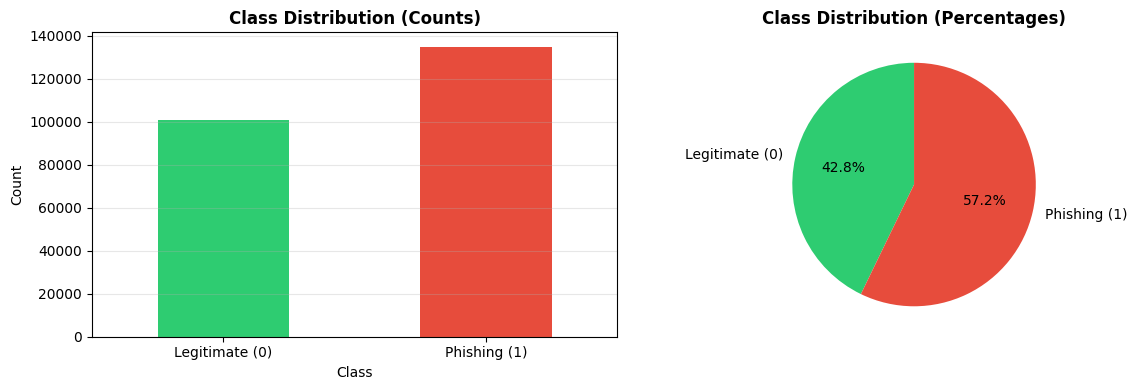


Imbalance Ratio: 1.34:1

FEATURE CORRELATION ANALYSIS

Top features correlated with label:
label                    1.000000
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
HasHiddenFields          0.507731
Name: label, dtype: float64


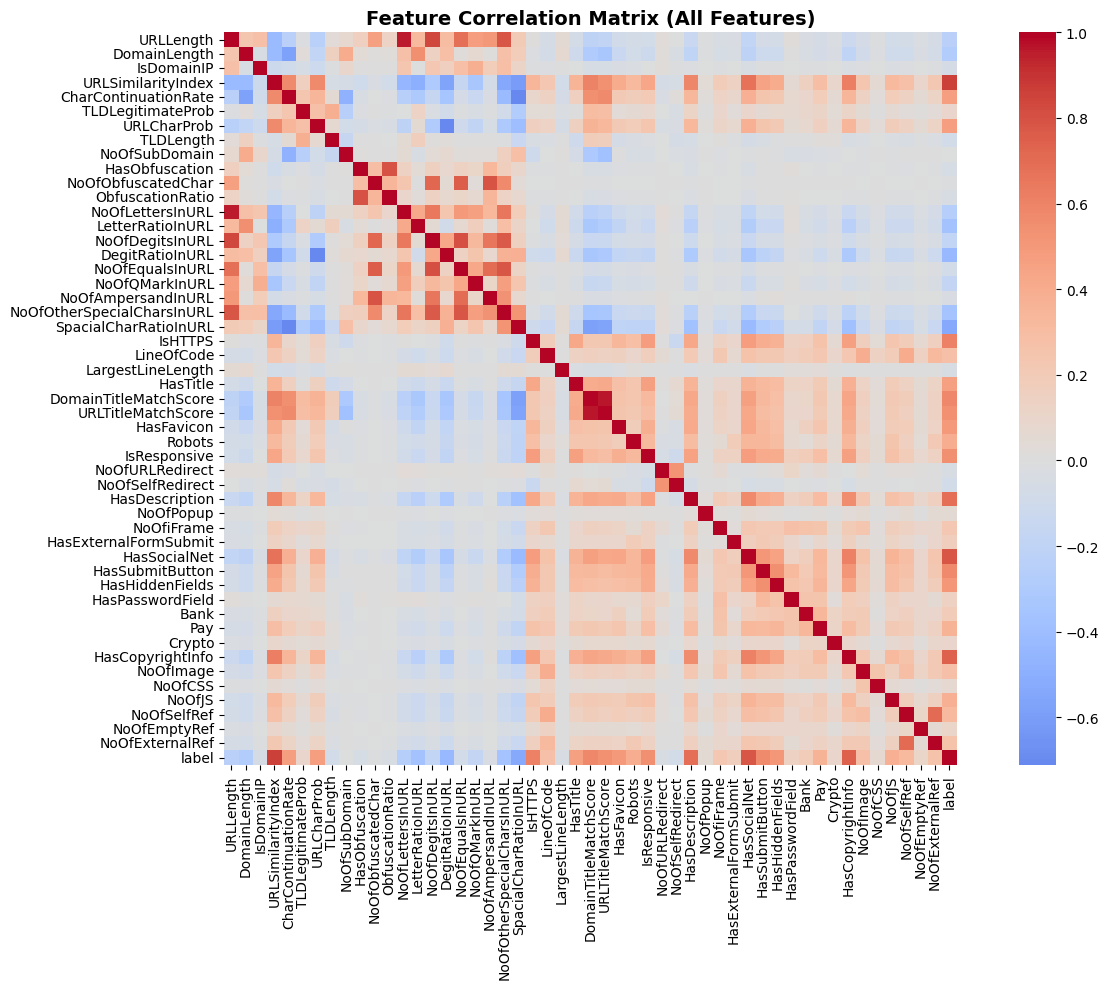

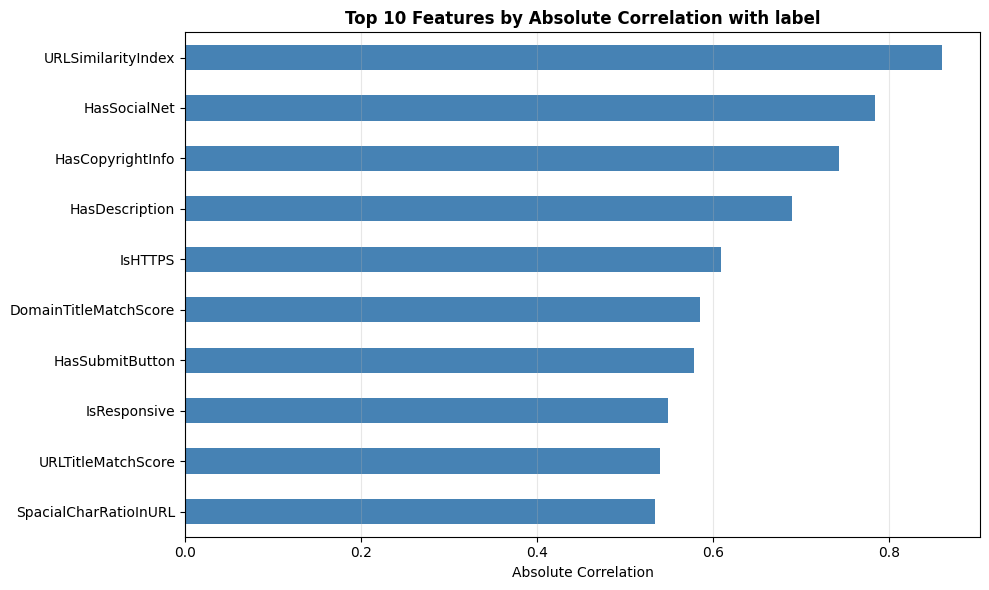


Top 10 features by correlation with target:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL    0.533537
Name: label, dtype: float64


In [6]:
# Day 1: Feature Correlation and Class Imbalance Analysis

# ============================================
# 1. CLASS IMBALANCE ANALYSIS
# ============================================
print("="*60)
print("CLASS IMBALANCE ANALYSIS")
print("="*60)

# Get the label column (it might be named 'label', 'class', or similar)
label_col = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower()][-1]

class_distribution = df[label_col].value_counts().sort_index()
class_distribution_pct = df[label_col].value_counts(normalize=True).sort_index() * 100

print(f"\nClass Distribution (Counts):")
print(class_distribution)
print(f"\nClass Distribution (Percentages):")
print(class_distribution_pct.round(2))

# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
class_distribution.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_distribution.values, labels=['Legitimate (0)', 'Phishing (1)'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentages)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = class_distribution.max() / class_distribution.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

# ============================================
# 2. FEATURE CORRELATION ANALYSIS
# ============================================
print("\n" + "="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# Calculate correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Get correlations with target
target_correlations = correlation_matrix[label_col].sort_values(ascending=False)
print(f"\nTop features correlated with {label_col}:")
print(target_correlations.head(11))

# Visualize correlation heatmap (full)
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix (All Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize top correlated features with target
top_n = 10
top_features_corr = target_correlations.drop(label_col).abs().nlargest(top_n)
plt.figure(figsize=(10, 6))
top_features_corr.sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Top {top_n} Features by Absolute Correlation with {label_col}', 
          fontsize=12, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features by correlation with target:")
print(top_features_corr.sort_values(ascending=False))